### *Team members*
Ελεάνα Λύτη    1115202100089 \
Γιώργος Ράγκος 1115202100167 \
Αλέξης Σούλι   1115202100174



# Initialization
---


## Depencies and imports

In [ ]:
!pip install --upgrade gensim datasets swifter wordcloud faiss-cpu kaleido

import pathlib, random, contextlib, io, re, csv, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.io as pio
import plotly.graph_objects as go
from textwrap import wrap
from IPython.display import display, Markdown, Image
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords, brown
from nltk.stem import PorterStemmer
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.sentiment.util import mark_negation

nltk.download('punkt_tab')
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('vader_lexicon')


from datasets import load_dataset
import swifter
import scipy
import faiss
import gensim.downloader as api

from scipy.sparse import csr_matrix
from sklearn.metrics.pairwise import cosine_similarity



from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import normalize, MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import silhouette_score, classification_report
from yellowbrick.cluster import SilhouetteVisualizer, KElbowVisualizer

pio.renderers.default = 'notebook'
categories = [
    "Appliances",
    "Software",
    "Industrial_and_Scientific",
    "Handmade_Products",
    "Health_and_Personal_Care"
]
f_width = 12
f_height = 7
MAX_ROWS = 200000



[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
/usr/local/lib/python3.11/dist-packages/kaleido/__init__.py:14: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.




In [ ]:
!pip install gensim
from gensim.models import KeyedVectors
from nltk.tokenize import word_tokenize
import numpy as np

In [ ]:
!pip install gensim

## Dataset Initialization

We define functions for retrieving the amazon product info and reviews datasets for the requested categories. These functions facilitate the convertion of the retrieved datasets to:

*   **Product info and Reviews dataframes**, returned to the caller for analysis
*   **Product info and Reviews CSVs**, written to the disk




In [ ]:
#fields for each dataset

fields_products = ["main_category","title","description", "average_rating", "rating_number","features", "price","parent_asin" ]
fields_reviews = ["rating","title", "text", "timestamp","parent_asin","user_id"]

# Convers a loaded streaming dataset to a csv file. set_type determines whether
# the dataset contains metadata or reviews.

def dataset_to_csv(dataset,filename,set_type):
  if set_type == "meta":
    fields = fields_products
  elif set_type == "review":
    fields = fields_reviews
  else:
    raise ValueError("Invalid set_type. Must be 'meta' or 'reviews'.")
  count = 0
  filename = f"{set_type}_{filename}"
  with open(filename, "w", newline="") as csvfile:
      writer = csv.DictWriter(csvfile, fieldnames=fields)
      writer.writeheader()

      for entry in dataset:
        if count > MAX_ROWS:
          break
        row = {field: entry.get(field, "") for field in fields}
        writer.writerow(row)
        count+=1

# Load both reviews and rating datasets for the given category, converts them
# to csv and returns a dataframe pair of the metadata and reviews.
def init_dataset(category):
    meta = load_dataset("McAuley-Lab/Amazon-Reviews-2023",f"raw_meta_{category}", split="full", streaming=True)
    reviews = load_dataset("McAuley-Lab/Amazon-Reviews-2023",f"raw_review_{category}", split="full", streaming=True)

    meta = meta.select_columns(fields_products)
    reviews = reviews.select_columns(fields_reviews)

    dataset_to_csv(meta,f"{category}.csv","meta")
    dataset_to_csv(reviews,f"{category}.csv","review")

    df_meta = pd.read_csv(f"meta_{category}.csv")
    df_reviews = pd.read_csv(f"review_{category}.csv")
    return df_meta, df_reviews

## Sanitization and text pre-processing

The main sanitization function clean_dataset accepts 2 dataframes


*   The `meta` dataframe, containing product info data
*   The `review` dataframe, containing user reviews

The function scales price fiels,fills NaNs, and pre-processes text



In [ ]:

# Performs dataset sanitization and text preprocessing for meta and review datasets
def clean_dataset(meta,review):

  def normalize_dataset(df):
    # clean rating_number field
    df["rating_number"] = pd.to_numeric(df["rating_number"], errors="coerce")
    df["rating_number"] = df["rating_number"].fillna(0)

    # clean price field
    df["price"] = pd.to_numeric(df["price"], errors="coerce")
    df["price"] = df["price"].fillna(0)

    # scale price field
    scaler = MinMaxScaler()
    df["price"] = np.log1p(df["price"])
    df["price"] = scaler.fit_transform(df[["price"]])
    nonzero_prices = df.loc[df["price"] != 0, "price"]
    median_val = np.median(nonzero_prices)
    df["price"] = df["price"].replace(0, median_val)

    # scale ratings field
    scaler = MinMaxScaler()
    df["average_rating"] = np.log1p(df["average_rating"])
    df["average_rating"] = scaler.fit_transform(df[["average_rating"]])
    nonzero_ratings = df.loc[df["average_rating"] != 0, "average_rating"]
    median_val = np.median(nonzero_ratings)
    df["average_rating"] = df["average_rating"].replace(0, median_val)

    return df

  # preproccess text
  def clean_text(text):
    try:
      if pd.isna(text) or text is None:
          return ""

      if not isinstance(text, str):
          text = str(text)

      text = re.sub(r'<.*?>', ' ', text)
      text = re.sub(r'\bbr\b', ' ', text, flags=re.IGNORECASE)
      text = re.sub(r"[^a-zA-Z\s]", "", text)
      text = text.lower()
      tokens = word_tokenize(text)                  # Tokenization
      tokens = [w for w in tokens if w not in stop_words]
      return " ".join(tokens)
    except Exception as e:
      print(f"Error processing text: {e}")
      return ""

  stop_words = set(stopwords.words("english"))

  meta["features"] = meta["features"].astype(str).apply(clean_text)
  meta["description"] = meta["description"].apply(lambda x: " ".join(x) if isinstance(x, list) else x)
  meta["description"] = meta["description"].astype(str).apply(clean_text)
  meta["description"] = meta["description"].fillna("")


  normalize_dataset(meta)
  # Clean review fields
  review["rating"] = pd.to_numeric(review["rating"], errors="coerce")
  review["text"] = review["text"].astype(str).apply(clean_text)

## Execution

In [ ]:

# Initialize, sanitize and write datasets to csv
for category in categories:
  print(f"Initializing {category}")
  meta,reviews = init_dataset(category)
  clean_dataset(meta,reviews)
  meta.to_csv(f"meta_{category}.csv", index=False)
  reviews.to_csv(f"review_{category}.csv", index=False)





Initializing Appliances


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning:


The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.



Initializing Software
Initializing Industrial_and_Scientific


/tmp/ipython-input-2-456957542.py:41: DtypeWarning:

Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.



Initializing Handmade_Products
Initializing Health_and_Personal_Care



# Clustering

We perform K-means clustering for all categories. For more effective clustering, the following pipeline was used:

1. **Vectorization of product descriptions using the TF-IDF method**, for more accurate clustering, price and average rating features were also appended to the resulting TF-IDF feature matrix. These features were scaled using MinMax scaling.

2. **Dimensionality reduction**, using Truncated Singular Value Decomposition for noise reduction and better K-means clustering performance.

3. **Hyperparameter tuning** of the number of clusters based on the resulting silhouette score after fitting using K-means. The range \[3, 70] was chosen for tuning based on observations from K-elbow estimations in the range \[2, 100], where all ideal K values were less than 40 < 70. 2 was excluded from the tuning range since it dominated other cluster count choices while providing little useful insight.

4. **Visualization** of the resulting clusters in 2 dimensions using t-SNE.


In [ ]:

def vectorize_products(meta,category,vectorizer,scaler):
  meta = meta[meta['description'].str.strip() != ""]
  meta = meta.dropna(subset=['description'])

  matrix = vectorizer.fit_transform(meta["description"])
  matrix = normalize(matrix)
  sparse_numerical = csr_matrix(meta[["price","average_rating"]])
  matrix = scipy.sparse.hstack([matrix, sparse_numerical])

  return matrix

In [ ]:
def compute_clusters(matrix,k):

  # Dimensionality reduction
  svd = TruncatedSVD(n_components=25, random_state=42)
  components = svd.fit_transform(matrix)

  model = KMeans(random_state=42)

  kmeans = KMeans(n_clusters=k, random_state=42)
  labels = kmeans.fit_predict(components)

  return labels,components



In [ ]:

def visualize_clusters(cluster_set, categories, perplexity=30):
    plt.figure(figsize=(15, 10))  # Adjust size as needed

    for idx, category in enumerate(categories):
        labels, components = cluster_set[category]

        # t-SNE transformation
        tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity)
        X_tsne = tsne.fit_transform(components)

        # Subplot
        plt.subplot(2, 3, idx + 1)  # 2x3 grid (up to 6 plots)
        plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels, cmap='tab10', s=10)
        plt.title(f"{category}")

    plt.tight_layout()
    plt.show()






In [ ]:
from scipy.sparse import csr_matrix

vectorizer = TfidfVectorizer(min_df=5,max_df=0.8)
scaler = MinMaxScaler()

categories = ["Appliances","Software","Industrial_and_Scientific","Handmade_Products","Health_and_Personal_Care"]

cluster_set = {}
for category in categories:
  max_k = (0,0)
  for k in range(3,70):
    meta = pd.read_csv(f"meta_{category}.csv")
    meta = meta.dropna()
    meta = meta.sample(n=10000, random_state=42)


    cluster_set[category] = vectorize_products(meta,category,vectorizer,scaler)
    labels,components = compute_clusters(cluster_set[category],k)

    max_k = max(max_k,(silhouette_score(components, labels),k))
    if max_k[1] == k:
      max_labels = labels
      max_components = components
  cluster_set[category] = (max_labels,max_components)


  print(f"Best k for {category}: {max_k[1]}")
  print(f"Silhouette Score for {category}: {max_k[0]}")

Best k for Appliances: 3
Silhouette Score for Appliances: 0.3923435869879335
Best k for Software: 33
Silhouette Score for Software: 0.1416421801586138
Best k for Industrial_and_Scientific: 4
Silhouette Score for Industrial_and_Scientific: 0.16095145262318905
Best k for Handmade_Products: 3
Silhouette Score for Handmade_Products: 0.539530919310473
Best k for Health_and_Personal_Care: 4
Silhouette Score for Health_and_Personal_Care: 0.24534177695683138


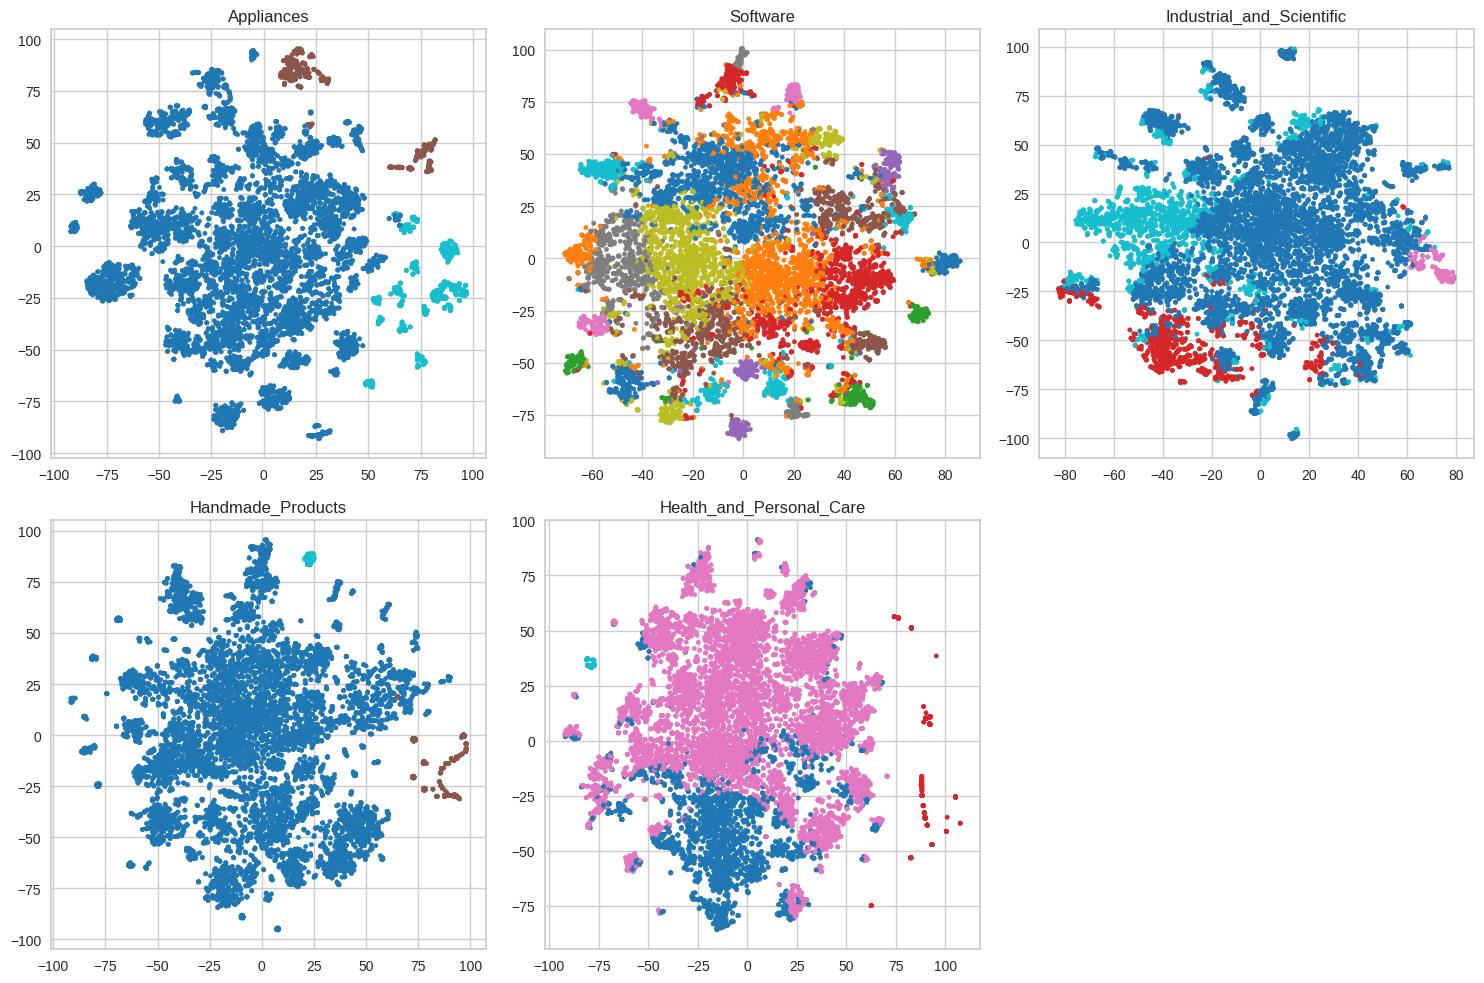

In [ ]:
visualize_clusters(cluster_set, categories)


## Clustering Limitations

While K-means clustering was applied across all categories, the results were less effective than expected. This is evident both from the cluster visualization plots, which showed overlapping and unclear groupings, and from the relatively low silhouette scores (mostly below 0.2), indicating weak cluster separation.

Several factors contributed to this outcome:

1. **TF-IDF representations** produce high-dimensional, sparse vectors. Even after dimensionality reduction, important structure may have been lost, making it harder to identify meaningful clusters.

2. **Curse of dimensionality** still affects the distance metrics used by K-means, reducing the reliability of cluster assignments in sparse and complex data spaces.

3. **K-means assumptions** such as spherical, equally sized clusters don’t seem to hold well for amazon product data, where descriptions overlap or are unclear.

4. **Amazon product data variability** in description length, vocabulary, and specificity introduces noise that complicates clustering.

5. **Additional features like price and rating**, although included, were not strong enough signals to improve clustering quality after scaling and dimensionality reduction.

Overall, these challenges limited K-means’ ability to produce clear and meaningful clusters on this dataset.



# Recommendation System

We implemented a Recomendation System. The following pipeline was used:
  1. Data Preprocessing:
   - Merging product metadata with user review datasets
   - Cleaning missing values and normalizing prices
  2. Representation Building:
    - Generating content-based embeddings using pre-trained GloVe word vectors
    - Creating a user-item rating matrix to support collaborative filtering computations
  3. Algorithms implementation:
   - Collaborative Filtering (CF)
   - Content-Based Filtering (CBF)
   - Hybrid Model

**Comparison of Different Recommendation Algorithms:**
  
  1. **Collaborative Filtering**:

   **Strengths:**
    - **Good recomendation scores**, produced the highest individual scores
    - **Personalization**, the recommendations are based on users preferences, behaviors, or interactions
  
     **Weaknesses:**
    - **Cold Start Problem**, CF has difficulties to users that have not a lot of interactions
    - **Incomplete data**, when the user matrix is sparse, CF underperfoms

  2. **Content-Based Filtering:**

     **Strengths:**
    - **No Cold Start for Users**, the reccomendation system can work even with few interactions

     **Weaknesses:**
    - **Lower Scores**, the result scores were lower and less personalized
   - **Limited Exploration**: It recommends items similar to those already rated, which may limit discovery of diverse products.

   3.**Hybrid Model:**

   **Strengths:**
   - **Higher Accuracy**, hybrid model uses both CF and CBF so the results is a combine of them with a weighted approach.
   -**One system reduces the challenges of the other**, CF struggles when there is sparse user interaction data, while CBF does not rely on other users, the hybrid approach balances out these weaknesses

   **Weaknesses:**
   - **Higher Computational Cost**,Combining multiple algorithms requires more memory and time.






In [ ]:

tqdm.pandas()
for pack in ["punkt", "stopwords"]:
    with contextlib.redirect_stdout(io.StringIO()):
        nltk.download(pack, quiet=True)
stop = set(stopwords.words("english"))


In [ ]:
category = "Software"
meta = pd.read_csv(f"meta_{category}.csv")
review = pd.read_csv(f"review_{category}.csv")

print(f"{len(meta):,} products – {len(review):,} reviews read")

meta["rating_number"] = pd.to_numeric(meta["rating_number"]).fillna(0).astype("int32")
meta["average_rating"] = pd.to_numeric(meta["average_rating"]).fillna(0).astype("float32")

# price normalization
meta["price"] = pd.to_numeric(meta["price"], errors='coerce')
if meta["price"].isna().all():
    meta["price"] = 0.0
else:
    meta["price"].fillna(meta["price"].median(), inplace=True)
    if meta["price"].max() > 1.01:
        meta["price"] = MinMaxScaler().fit_transform(meta[["price"]]).astype("float32")

# text feuatures combined
meta["title"] = meta["title"].fillna("").astype(str)
meta["description"] = meta["description"].fillna("").astype(str)
meta["features"] = meta["features"].fillna("").astype(str) if "features" in meta else ""
meta["combined"] = meta["title"] + " " + meta["description"] + " " + meta["features"]


89,251 products – 200,001 reviews read


In [ ]:
# Load pre-trained GloVe word embeddings
print("Loading GloVe embeddings...")
word2vec = api.load("glove-wiki-gigaword-100")
size = word2vec.vector_size


# Function to convert text to vector
def text_to_vector(text: str) -> np.ndarray:
    tokens = word_tokenize(text.lower())
    vecs = [word2vec[tok] for tok in tokens if len(tok) > 2 and tok not in stop and tok in word2vec]
    return np.mean(vecs, axis=0) if vecs else np.zeros(size)

# Embeddings for all items based on their combined text
meta["emb"] = meta["combined"].progress_apply(text_to_vector)
# Stack all embeddings into a matrix and convert to float32
emb_matrix = np.vstack(meta["emb"].to_list()).astype("float32")

# Normalize vectors
faiss.normalize_L2(emb_matrix)

index = faiss.IndexFlatIP(size)
index.add(emb_matrix)
asin_to_idx = {asin: i for i, asin in enumerate(meta["parent_asin"])}


Loading GloVe embeddings...
[==================================================] 100.0% 128.1/128.1MB downloaded


100%|██████████| 89251/89251 [01:41<00:00, 879.40it/s]


In [ ]:
# Filters review data to active users (5+ reviews) and valid products, then constructs
# a user-item rating matrix for collaborative filtering. Converts to sparse format
# and computes user-user cosine similarities for recommendation generation.

# number of reviews per user
user_counts = review["user_id"].value_counts()
# Select users with at least 5 reviews and keep 10000 users
top_users = user_counts[user_counts >= 5].index[:20000]

valid_asins = set(meta["parent_asin"])
filtered_reviews = review[
    (review["user_id"].isin(top_users)) &
    (review["parent_asin"].isin(valid_asins))
]

user_item_matrix = filtered_reviews.pivot_table(index="user_id", columns="parent_asin", values="rating").fillna(0)

user_item_sparse = csr_matrix(user_item_matrix.values)

user_sim_matrix = cosine_similarity(user_item_sparse)

user_items = user_item_matrix.copy()


In [ ]:
#Generates personalized recommendations using user-user similarity
#for a target user and finds k-nearest neighbors based on rating

def collaborative_filtering(user_id, k_neighbors=5):
    if user_id not in user_item_matrix.index:
        return pd.Series(dtype=float)

    user_idx = user_item_matrix.index.get_loc(user_id)
    #similarity scores for the target user
    user_sim_vector = user_sim_matrix[user_idx]

    # Convert similarity vector to a Series index
    similarities = pd.Series(user_sim_vector, index=user_item_matrix.index)
    similarities = similarities.drop(user_id).sort_values(ascending=False).head(k_neighbors)

    sim_ratings = user_item_matrix.loc[similarities.index]
    cf_scores = sim_ratings.T.dot(similarities) / similarities.sum()

    return cf_scores


In [ ]:
print("\n" + "="*20 + " COLLABORATIVE FILTERING RESULTS " + "="*20)
sample_users = user_item_matrix.index[:5]

for uid in sample_users:
    print(f"\nTop CF recommendations for user: {uid}")
    cf_scores = collaborative_filtering(uid, k_neighbors=5).sort_values(ascending=False).head(5)
    for asin, score in cf_scores.items():
        title = meta.loc[meta["parent_asin"] == asin, "title"].values
        title = title[0] if len(title) else "Unknown"
        print(f"  - ASIN: {asin} | Title: {title[:60]} | CF Score: {score:.3f}")



==================== COLLABORATIVE FILTERING RESULTS ====================

Top CF recommendations for user: AE22GFDZWHSMCA3PZP6WB3OJUHEQ
  - ASIN: B00CKOYVG8 | Title: Angry Birds Friends | CF Score: 4.279
  - ASIN: B009HQ9UHC | Title: Bad Piggies Free | CF Score: 2.187
  - ASIN: B01248YO8E | Title: Colorfy: Free Coloring Book for Adults - Best Coloring Apps  | CF Score: 1.901
  - ASIN: B005ZXWMUS | Title: Netflix | CF Score: 1.635
  - ASIN: B008HPRQ3Y | Title: Fitbit | CF Score: 1.005

Top CF recommendations for user: AE22MRZKBD5MWJLIMGYLLJ67ZWVQ
  - ASIN: B0094BB4TW | Title: Facebook | CF Score: 3.575
  - ASIN: B005ZXWMUS | Title: Netflix | CF Score: 3.470
  - ASIN: B004SIIBGU | Title: eBay - Buy, Sell & Save Money | CF Score: 2.138
  - ASIN: B009G9KFQ0 | Title: WeatherBug - Free Local Weather Forecast, Radar Map & Severe | CF Score: 2.129
  - ASIN: B00L0T4VL4 | Title: Jigsaw Puzzles Epic | CF Score: 1.895

Top CF recommendations for user: AE22WTKMX7A2FMFIF36XBJ5YVENQ
  - ASIN: B0172

In [ ]:
#Generates recommendations based on item content similarity to user's liked items

def content_based_filtering(user_id, candidate_items):
    # Get items the user has rated
    liked_items = user_item_matrix.loc[user_id]
    liked_items = liked_items[liked_items > 0].index.tolist()

    vecs = [emb_matrix[asin_to_idx[a]] for a in liked_items if a in asin_to_idx]
    if not vecs:
        return pd.Series(0, index=candidate_items)

    #Computes the average vector of liked item embeddings
    query_vec = np.mean(vecs, axis=0, keepdims=True)
    faiss.normalize_L2(query_vec)
    #Searching similar items in the FAISS index
    sims, idxs = index.search(query_vec, len(candidate_items))

    candidate_asins = meta.iloc[idxs[0]]["parent_asin"].values
     #Create a Series with similarity scores
    cbf_scores = pd.Series(sims[0], index=candidate_asins)
    cbf_scores = cbf_scores.reindex(candidate_items).fillna(0)

    return cbf_scores


In [ ]:
print("\n" + "="*20 + " CONTENT-BASED FILTERING RESULTS " + "="*20)
for uid in sample_users:
    print(f"\nTop CBF recommendations for user: {uid}")
    candidate_items = user_item_matrix.columns
    cbf_scores = content_based_filtering(uid, candidate_items=candidate_items).sort_values(ascending=False).head(5)
    for asin, score in cbf_scores.items():
        title = meta.loc[meta["parent_asin"] == asin, "title"].values
        title = title[0] if len(title) else "Unknown"
        print(f"  - ASIN: {asin} | Title: {title[:60]} | CBF Score: {score:.3f}")



==================== CONTENT-BASED FILTERING RESULTS ====================

Top CBF recommendations for user: AE22GFDZWHSMCA3PZP6WB3OJUHEQ
  - ASIN: B009HQ9UHC | Title: Bad Piggies Free | CBF Score: 0.986
  - ASIN: B009G1J62C | Title: Bad Piggies Premium | CBF Score: 0.986
  - ASIN: B00ZZH696M | Title: Horse Survival Simulator | CBF Score: 0.983
  - ASIN: B01N76WV5I | Title: Toca Life: Stable | CBF Score: 0.982
  - ASIN: B073RLFP9N | Title: Monster Busters: Ice Slide | CBF Score: 0.981

Top CBF recommendations for user: AE22MRZKBD5MWJLIMGYLLJ67ZWVQ
  - ASIN: B00DZI9BFY | Title: COCOPPA - ICON/WALLPAPER FREE | CBF Score: 0.989
  - ASIN: B005ZKDVYC | Title: Serif WebPlus X5 | CBF Score: 0.986
  - ASIN: B005ZKDVC4 | Title: Serif WebPlus X4 | CBF Score: 0.985
  - ASIN: B00HEVJU7W | Title: Nick - Watch TV Shows & Videos | CBF Score: 0.984
  - ASIN: B00J35V8SG | Title: MyPOD V2 Podcast Manager | CBF Score: 0.984

Top CBF recommendations for user: AE22WTKMX7A2FMFIF36XBJ5YVENQ
  - ASIN: B012P2

In [ ]:
#Generates recommendations by combining collaborative and content-based filtering.

def hybrid_recommend(user_id, top_k=10, k_neighbors=5, cf_weight=0.7, cbf_weight=0.3):
    cf_scores = collaborative_filtering(user_id, k_neighbors=k_neighbors)

    if cf_scores.empty:
        return pd.Series(dtype=float)

    cbf_scores = content_based_filtering(user_id, candidate_items=cf_scores.index)

    hybrid_scores = cf_weight * cf_scores + cbf_weight * cbf_scores

    already_rated = user_item_matrix.loc[user_id]
    already_rated = already_rated[already_rated > 0].index


    return hybrid_scores.sort_values(ascending=False).head(top_k)


In [ ]:
sample_users = user_item_matrix.index[:5]

for uid in sample_users:
    print(f"\nTop hybrid recommendations for user: {uid}")
    top_recs = hybrid_recommend(uid, top_k=5)
    for asin, score in top_recs.items():
        title = meta.loc[meta["parent_asin"] == asin, "title"].values
        title = title[0] if len(title) else "Unknown"
        print(f"  - ASIN: {asin} | Title: {title[:60]} | Hybrid Score: {score:.3f}")




Top hybrid recommendations for user: AE22GFDZWHSMCA3PZP6WB3OJUHEQ
  - ASIN: B00CKOYVG8 | Title: Angry Birds Friends | Hybrid Score: 3.282
  - ASIN: B009HQ9UHC | Title: Bad Piggies Free | Hybrid Score: 1.827
  - ASIN: B01248YO8E | Title: Colorfy: Free Coloring Book for Adults - Best Coloring Apps  | Hybrid Score: 1.613
  - ASIN: B005ZXWMUS | Title: Netflix | Hybrid Score: 1.144
  - ASIN: B00FB13Y74 | Title: Angry Birds Go! | Hybrid Score: 0.942

Top hybrid recommendations for user: AE22MRZKBD5MWJLIMGYLLJ67ZWVQ
  - ASIN: B0094BB4TW | Title: Facebook | Hybrid Score: 2.787
  - ASIN: B005ZXWMUS | Title: Netflix | Hybrid Score: 2.711
  - ASIN: B004SIIBGU | Title: eBay - Buy, Sell & Save Money | Hybrid Score: 1.779
  - ASIN: B009G9KFQ0 | Title: WeatherBug - Free Local Weather Forecast, Radar Map & Severe | Hybrid Score: 1.490
  - ASIN: B00T6OFVO6 | Title: Words With Friends | Hybrid Score: 1.454

Top hybrid recommendations for user: AE22WTKMX7A2FMFIF36XBJ5YVENQ
  - ASIN: B017250D16 | Title: 

#Classification - Sentiment Analysis


**Sentiment Labeling with VADER and Rating Information**

This section is used to compute sentiment labels for customer reviews, combining VADER sentiment scores and user ratings. Output is a label to show whether the sentiment is positive, neutral or negative. It creates a new CSV file with the sentiments only for the first 50000 rows, since the datasets are very large.

In [ ]:
import pandas as pd
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import os

# Download VADER lexicon
import nltk
nltk.download('vader_lexicon')

# Categories to process
categories = [
    "Appliances",
    "Handmade_Products",
    "Health_and_Personal_Care",
    "Industrial_and_Scientific",
    "Software"
]

# Initialization of VADER
sid = SentimentIntensityAnalyzer()

# Classifying sentiment into 3 categories
def compute_sentiment_label(row):
    compound = sid.polarity_scores(row['text'])['compound']
    norm_vader = (compound + 1) / 2
    rating_scaled = (row['rating'] - 1) / 4
    combined_score = 0.4 * norm_vader + 0.6 * rating_scaled
    if combined_score >= 0.65:
        return "positive"
    elif combined_score <= 0.35:
        return "negative"
    else:
        return "neutral"

# Process each file
for category in categories:
    file_path = f"review_{category}.csv"
    if not os.path.exists(file_path):
        print(f" File not found: {file_path}")
        continue

    print(f" Processing: {file_path}")

    # Load only first 100,000 rows
    df = pd.read_csv(file_path, nrows=50000)
    df["text"] = df["text"].astype(str)
    df["rating"] = pd.to_numeric(df["rating"], errors="coerce").fillna(0)

    # Apply sentiment labeling
    df["sentiment_label"] = df.apply(compute_sentiment_label, axis=1)

    # Save labeled file
    output_path = f"review_{category}_with_sentiment.csv"
    df.to_csv(output_path, index=False)
    print(f" Saved: {output_path}")

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


 Processing: review_Appliances.csv
 Saved: review_Appliances_with_sentiment.csv
 Processing: review_Handmade_Products.csv
 Saved: review_Handmade_Products_with_sentiment.csv
 Processing: review_Health_and_Personal_Care.csv
 Saved: review_Health_and_Personal_Care_with_sentiment.csv
 Processing: review_Industrial_and_Scientific.csv
 Saved: review_Industrial_and_Scientific_with_sentiment.csv
 Processing: review_Software.csv
 Saved: review_Software_with_sentiment.csv


This script performs sentiment classification using TF-IDF features across multiple product review datasets.
For each dataset and model combination, it computes:
  - Test set evaluation metrics: Precision, Recall, F1-Score, Accuracy (all macro-averaged)
  - 10-fold cross-validation on the training set (F1 macro)

Evaluated models:
  - Multinomial Naive Bayes
  - K-Nearest Neighbors (k=5)
  - Random Forest (30 trees)

In [ ]:
import pandas as pd
import os
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# Dataset categories
categories = [
    "Appliances",
    "Handmade_Products",
    "Health_and_Personal_Care",
    "Industrial_and_Scientific",
    "Software"
]

# Models to evaluate
models = {
    "Naive Bayes": MultinomialNB(),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Random Forest": RandomForestClassifier(
        n_estimators=30,
        random_state=42,
        n_jobs=-1
    )
}

# Go through datasets
for category in categories:
    file = f"review_{category}_with_sentiment.csv"
    if not os.path.exists(file):
        print(f" File not found: {file}")
        continue

    print(f"\n Processing: {file}")

    # Load and preprocess
    df = pd.read_csv(file)
    df = df.sample(n=50000, random_state=42).copy() if len(df) > 50000 else df
    df["text"] = df["text"].fillna("").astype(str)
    label_map = {"positive": 2, "neutral": 1, "negative": 0}
    df["sentiment_label"] = df["sentiment_label"].map(label_map)

    # TF-IDF Features
    tfidf = TfidfVectorizer(max_features=1000)
    X = tfidf.fit_transform(df["text"])
    y = df["sentiment_label"]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Collect per-dataset results
    results = []

    # Train and evaluate all models
    for model_name, model in models.items():
        print(f" Evaluating {model_name} on {category}...")

        # Fit on train
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        # Evaluation on test set
        precision = precision_score(y_test, y_pred, average="macro")
        recall = recall_score(y_test, y_pred, average="macro")
        f1 = f1_score(y_test, y_pred, average="macro")
        accuracy = accuracy_score(y_test, y_pred)

        # 10-fold CV on train set
        try:
            cv_f1 = cross_val_score(model, X_train, y_train, cv=10, scoring='f1_macro', n_jobs=-1).mean()
        except Exception as e:
            print(f" CV failed for {model_name}: {e}")
            cv_f1 = None

        results.append({
            "Feature Set": "TF-IDF",
            "Dataset": category,
            "Model": model_name,
            "Precision": round(precision, 4),
            "Recall": round(recall, 4),
            "F1-Score": round(f1, 4),
            "Accuracy": round(accuracy, 4),
            "10-Fold CV F1": round(cv_f1, 4) if cv_f1 else "N/A"
        })

    # Print per-dataset results
    results_df = pd.DataFrame(results)
    print(f"\n Evaluation Results (TF-IDF) — {category}:")
    print(results_df.to_markdown(index=False))





 Processing: review_Appliances_with_sentiment.csv
 Evaluating Naive Bayes on Appliances...
 Evaluating KNN on Appliances...
 Evaluating Random Forest on Appliances...

 Evaluation Results (TF-IDF) — Appliances:
| Feature Set   | Dataset    | Model         |   Precision |   Recall |   F1-Score |   Accuracy |   10-Fold CV F1 |
|:--------------|:-----------|:--------------|------------:|---------:|-----------:|-----------:|----------------:|
| TF-IDF        | Appliances | Naive Bayes   |      0.6605 |   0.3827 |     0.3886 |     0.8305 |          0.3864 |
| TF-IDF        | Appliances | KNN           |      0.4456 |   0.4013 |     0.4117 |     0.7857 |          0.4094 |
| TF-IDF        | Appliances | Random Forest |      0.6381 |   0.4706 |     0.4912 |     0.844  |          0.4852 |

 Processing: review_Handmade_Products_with_sentiment.csv
 Evaluating Naive Bayes on Handmade_Products...
 Evaluating KNN on Handmade_Products...
 Evaluating Random Forest on Handmade_Products...

 Evaluation

# **Word Embedding Evaluation with Cross-Validation**
This script performs sentiment classification on multiple product review datasets using pre-trained word embeddings (GloVe 100d).
Each review is represented as the average of its word vectors. For every dataset, the following steps are executed:

1. Preprocessing and label encoding.
2. Embedding-based feature extraction.
3. Train-test split.
4. Model training using three classifiers:
   - Naive Bayes (GaussianNB)
   - K-Nearest Neighbors (KNN)
   - Random Forest
5. Evaluation on the test set using:
   - Precision (Macro)
   - Recall (Macro)
   - F1-Score (Macro)
   - Accuracy
6. 10-Fold Cross-Validation on the training data using F1-Score (Macro)

In [ ]:
import pandas as pd
import numpy as np
import os
import nltk
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import gensim.downloader as api

# Ensure punkt is downloaded
nltk.download("punkt")

# Load GloVe embeddings once
print(" Loading word embeddings...")
word_vectors = api.load("glove-wiki-gigaword-100")
embedding_dim = word_vectors.vector_size

# Helper to get average word vectors
def get_review_vector(text):
    tokens = word_tokenize(text.lower())
    vectors = [word_vectors[word] for word in tokens if word in word_vectors]
    return np.mean(vectors, axis=0) if vectors else np.zeros(embedding_dim)

# Dataset categories
categories = [
    "Appliances",
    "Handmade_Products",
    "Health_and_Personal_Care",
    "Industrial_and_Scientific",
    "Software"
]

# Models to evaluate
models = {
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Random Forest": RandomForestClassifier(
        n_estimators=30,
        random_state=42,
        n_jobs=-1
    )
}

# Loop through datasets
for category in categories:
    file = f"review_{category}_with_sentiment.csv"
    if not os.path.exists(file):
        print(f" File not found: {file}")
        continue

    print(f"\nProcessing: {file}")

    # Load and preprocess
    df = pd.read_csv(file)
    df = df.sample(n=50000, random_state=42).copy() if len(df) > 25000 else df
    df["text"] = df["text"].fillna("").astype(str)

    label_map = {"positive": 2, "neutral": 1, "negative": 0}
    df["sentiment_label"] = df["sentiment_label"].map(label_map)

    # Vectorize using word embeddings
    print("Generating embedding vectors...")
    X = np.vstack(df["text"].apply(get_review_vector))
    y = df["sentiment_label"]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Store per-category results
    results_embed = []

    for model_name, model in models.items():
        print(f"Evaluating {model_name} on {category} (Embeddings)...")
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        # Test set evaluation
        precision = precision_score(y_test, y_pred, average="macro")
        recall = recall_score(y_test, y_pred, average="macro")
        f1 = f1_score(y_test, y_pred, average="macro")
        accuracy = accuracy_score(y_test, y_pred)

        # 10-fold CV on training set
        try:
            cv_f1 = cross_val_score(model, X_train, y_train, cv=10, scoring='f1_macro', n_jobs=-1).mean()
        except Exception as e:
            print(f" CV failed for {model_name}: {e}")
            cv_f1 = None

        results_embed.append({
            "Feature Set": "Embeddings",
            "Dataset": category,
            "Model": model_name,
            "Precision": round(precision, 4),
            "Recall": round(recall, 4),
            "F1-Score": round(f1, 4),
            "Accuracy": round(accuracy, 4),
            "10-Fold CV F1": round(cv_f1, 4) if cv_f1 else "N/A"
        })

    # Print results table per dataset
    df_embed_results = pd.DataFrame(results_embed)
    print(f"\n Evaluation Results (Embeddings) — {category}:")
    print(df_embed_results.to_markdown(index=False))

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


 Loading word embeddings...

Processing: review_Appliances_with_sentiment.csv
Generating embedding vectors...
Evaluating Naive Bayes on Appliances (Embeddings)...
Evaluating KNN on Appliances (Embeddings)...
Evaluating Random Forest on Appliances (Embeddings)...

 Evaluation Results (Embeddings) — Appliances:
| Feature Set   | Dataset    | Model         |   Precision |   Recall |   F1-Score |   Accuracy |   10-Fold CV F1 |
|:--------------|:-----------|:--------------|------------:|---------:|-----------:|-----------:|----------------:|
| Embeddings    | Appliances | Naive Bayes   |      0.3966 |   0.4556 |     0.3473 |     0.5101 |          0.3484 |
| Embeddings    | Appliances | KNN           |      0.4995 |   0.4105 |     0.4277 |     0.8116 |          0.4392 |
| Embeddings    | Appliances | Random Forest |      0.5991 |   0.3759 |     0.3797 |     0.8242 |          0.3658 |

Processing: review_Handmade_Products_with_sentiment.csv
Generating embedding vectors...
Evaluating Naive Bay

#FINAL TEST EVALUATION
This script evaluates three machine learning models—Naive Bayes, K-Nearest Neighbors (KNN), and Random Forest.
This provides a snapshot of each model's generalization performance on unseen data after training.

In [ ]:
import pandas as pd
import os
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

#Dataset to evaluate
category = "Software"
file = f"review_{category}_with_sentiment.csv"

# Models
models = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(n_estimators=30, random_state=42, n_jobs=-1)
}

# Check file exists
if not os.path.exists(file):
    print(f" File not found: {file}")
else:
    # Load data
    df = pd.read_csv(file)
    df = df.sample(n=50000, random_state=42).copy() if len(df) > 10000 else df
    df["text"] = df["text"].fillna("").astype(str)

    label_map = {"positive": 2, "neutral": 1, "negative": 0}
    df["sentiment_label"] = df["sentiment_label"].map(label_map)

    # TF-IDF
    tfidf = TfidfVectorizer(max_features=1000)
    X = tfidf.fit_transform(df["text"])
    y = df["sentiment_label"]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Results
    results_test = []

    for model_name, model in models.items():
        print(f"Final Test Evaluation: {model_name}")
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        precision = precision_score(y_test, y_pred, average="macro")
        recall = recall_score(y_test, y_pred, average="macro")
        f1 = f1_score(y_test, y_pred, average="macro")
        accuracy = accuracy_score(y_test, y_pred)

        results_test.append({
            "Model": model_name,
            "Precision": round(precision, 4),
            "Recall": round(recall, 4),
            "F1-Score": round(f1, 4),
            "Accuracy": round(accuracy, 4)
        })

    # Print final test evaluation table
    df_final_test = pd.DataFrame(results_test)
    print("\n Final Test Set Evaluation Table:")
    print(df_final_test.to_markdown(index=False))

Final Test Evaluation: KNN
Final Test Evaluation: Naive Bayes
Final Test Evaluation: Random Forest

 Final Test Set Evaluation Table:
| Model         |   Precision |   Recall |   F1-Score |   Accuracy |
|:--------------|------------:|---------:|-----------:|-----------:|
| KNN           |      0.4885 |   0.5126 |     0.4823 |     0.6033 |
| Naive Bayes   |      0.654  |   0.494  |     0.5109 |     0.7366 |
| Random Forest |      0.6615 |   0.5823 |     0.5971 |     0.7646 |
